# Data Loading and Cleaning

**Steps**
1. Load dataset
2. Check data types and convert mismatches
3. Inspect dataset for missing values
4. Check for outliers
5. Check for errors in data

**Cleaned columns**
1. Defined datatypes
2. Cleaned Course Type category
3. Converted Course Duration to categorical
4. Renamed Course Fee Subsidiy to Subsidy column

**Findings**
1. Signficant number (68%) of missing values in Number of learners, Number of Learners who rated, and Ratings
2. Outliers found in Course Fee, Course Hours indicating longer courses and qualifications compared to rest of dataset which are mostly short courses
3. Inconsistent rows where the number of learners rated is higher than the total number of learners

In [ ]:
# Import required packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset and check loading
df = pd.read_csv('SSG_Healthcare_Courses_Dataset.csv', encoding='latin-1')
display(df.head())
display(df.shape)

,ID,Course Title,Course Description,Training Company,Course Fee,Course Fee after Maximum Subsidiy,Course Type,Course Duration,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced
0,1,Nitec in Nursing,This course provides students with skills and ...,Institute Of Technical Education,860.0,0,Part time,More than 1 year,2800.0,NaN,NaN,NaN,2015
1,2,Nitec in Opticianry,The Nitec in Opticianry course provides studen...,Institute Of Technical Education,860.0,0,Part time,More than 1 year,2800.0,NaN,NaN,NaN,2015
2,3,Higher Nitec in Paramedic & Emergency Care,This course is to provide students with in-dep...,Institute Of Technical Education,885.0,0,Full Time and Part Time,More than 1 year,2100.0,NaN,NaN,NaN,2015
3,4,Doctor of Medicine (MD),The Duke-NUS Doctor of Medicine (MD) programme...,National University Of Singapore,306075.0,0,Part time,More than 1 year,6143.0,NaN,NaN,NaN,2015
4,5,Doctor of Philosophy,The MSc and PhD programmes are research-intens...,National University Of Singapore,211000.0,0,Part time,More than 1 year,7520.0,NaN,NaN,NaN,2015


(1703, 13)

In [ ]:
# Check original datatypes of columns
display(df.dtypes)

,0
ID,int64
Course Title,object
Course Description,object
Training Company,object
Course Fee,float64
Course Fee after Maximum Subsidiy,object
Course Type,object
Course Duration,object
Course Hours,float64
No. of Learners,float64


In [ ]:
# Create a copy for cleaning
df_clean = df.copy()

# Convert 'ID' to string
df_clean['ID'] = df_clean['ID'].astype(str)

# Convert 'Course Fee after Maximum Subsidiy' to float, fill NaNs with 0
df_clean['Course Fee after Maximum Subsidiy'] = pd.to_numeric(df_clean['Course Fee after Maximum Subsidiy'], errors='coerce').fillna(0)

# Convert 'Year of Course Introduced' to Year datetime type
df_clean['Year of Course Introduced'] = pd.to_datetime(df_clean['Year of Course Introduced'], format='%Y').dt.year

# Rename Subsidiy to Subsidy
df_clean.rename(columns={'Course Fee after Maximum Subsidiy': 'Course Fee after Maximum Subsidy'}, inplace=True)

# Check df_clean after conversions
print("\nData types of df_clean after conversion and renaming:")
display(df_clean.dtypes)
display(df_clean.head())


Data types of df_clean after conversion and renaming:


,0
ID,object
Course Title,object
Course Description,object
Training Company,object
Course Fee,float64
Course Fee after Maximum Subsidy,float64
Course Type,object
Course Duration,object
Course Hours,float64
No. of Learners,float64


,ID,Course Title,Course Description,Training Company,Course Fee,Course Fee after Maximum Subsidy,Course Type,Course Duration,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced
0,1,Nitec in Nursing,This course provides students with skills and ...,Institute Of Technical Education,860.0,0.0,Part time,More than 1 year,2800.0,NaN,NaN,NaN,2015
1,2,Nitec in Opticianry,The Nitec in Opticianry course provides studen...,Institute Of Technical Education,860.0,0.0,Part time,More than 1 year,2800.0,NaN,NaN,NaN,2015
2,3,Higher Nitec in Paramedic & Emergency Care,This course is to provide students with in-dep...,Institute Of Technical Education,885.0,0.0,Full Time and Part Time,More than 1 year,2100.0,NaN,NaN,NaN,2015
3,4,Doctor of Medicine (MD),The Duke-NUS Doctor of Medicine (MD) programme...,National University Of Singapore,306075.0,0.0,Part time,More than 1 year,6143.0,NaN,NaN,NaN,2015
4,5,Doctor of Philosophy,The MSc and PhD programmes are research-intens...,National University Of Singapore,211000.0,0.0,Part time,More than 1 year,7520.0,NaN,NaN,NaN,2015


In [ ]:
# Check for missing values
missing_values_count = df_clean.isna().sum()

# Calculate total number of rows
total_rows = len(df_clean)

# Calculate percentage missing
percentage_missing = (missing_values_count / total_rows) * 100

# Summary of missing values
missing_values_summary = pd.DataFrame({
    'Total Rows': total_rows,
    'Missing Values': missing_values_count,
    'Percentage Missing': percentage_missing
})

print("\nSummary of missing values per column:")
display(missing_values_summary.style.format({'Percentage Missing': "{:.2f}%"}))


Summary of missing values per column:


,Total Rows,Missing Values,Percentage Missing
ID,1703,0,0.00%
Course Title,1703,0,0.00%
Course Description,1703,0,0.00%
Training Company,1703,0,0.00%
Course Fee,1703,0,0.00%
Course Fee after Maximum Subsidy,1703,0,0.00%
Course Type,1703,0,0.00%
Course Duration,1703,0,0.00%
Course Hours,1703,0,0.00%
No. of Learners,1703,1063,62.42%


In [ ]:
# Describe numerical data
display(df_clean.describe())

,Course Fee,Course Fee after Maximum Subsidy,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced
count,1703.000000,1703.000000,1703.000000,640.000000,538.000000,538.000000,1703.000000
mean,6392.109618,351.864974,185.004645,90.300000,55.111524,4.292379,2022.939518
std,30625.466303,733.995095,699.020503,239.916862,142.650550,0.411200,1.834961
min,20.000000,0.000000,0.330000,1.000000,1.000000,1.000000,2015.000000
25%,275.230000,0.000000,9.000000,16.000000,7.000000,4.100000,2023.000000
50%,1200.000000,50.000000,24.000000,31.000000,19.000000,4.300000,2024.000000
75%,3915.000000,470.775000,60.000000,74.250000,39.000000,4.500000,2024.000000
max,644037.000000,19325.000000,8000.000000,3887.000000,1610.000000,5.000000,2025.000000


In [ ]:
print("Value counts for 'Course Duration':")
display(df_clean['Course Duration'].value_counts())

print("\nValue counts for 'Course Type':")
display(df_clean['Course Type'].value_counts())

print("\nValue counts for 'Year of Course Introduced':")
display(df_clean['Year of Course Introduced'].value_counts().sort_index())

Value counts for 'Course Duration':


,count
Course Duration,
1-2 days,590
3-5 days,430
6 days - 1 month,380
1-3 months,191
3-12 months,62
More than 1 year,50



Value counts for 'Course Type':


,count
Course Type,
Part Time,783
Part time,538
Full Time and Part Time,216
Full Time,166



Value counts for 'Year of Course Introduced':


,count
Year of Course Introduced,
2015,22
2016,4
2017,14
2018,25
2019,30
2020,94
2021,84
2022,132
2023,385


In [ ]:
# Fix Course Type values for Part time
df_clean['Course Type'] = df_clean['Course Type'].str.replace('Part time', 'Part Time')

# Convert Course Duration to ordinal datatype
course_duration_order = ['1-2 days', '3-5 days', '6 days - 1 month', '1-3 months', '3-12 months', 'More than 1 year']
df_clean['Course Duration'] = pd.Categorical(df_clean['Course Duration'], categories=course_duration_order, ordered=True)

# Checks
print("Value counts for 'Course Duration':")
display(df_clean['Course Duration'].value_counts())

print("\nValue counts for 'Course Type':")
display(df_clean['Course Type'].value_counts())


Value counts for 'Course Duration':


,count
Course Duration,
1-2 days,590
3-5 days,430
6 days - 1 month,380
1-3 months,191
3-12 months,62
More than 1 year,50



Value counts for 'Course Type':


,count
Course Type,
Part Time,1321
Full Time and Part Time,216
Full Time,166


# Data Exploration

**Summary**
1. Course hours are consistent with Course Duration
2. Course Fees for certain training companies are significantly higher than others
3.  Some companies have a lot more missing learners data than others
4. More courses in 2024 than other years
5. Ratings left skewed, other numeric columns right skewed with extreme outliers
6. Correlation between Course Fees and Course Hours
7. Subsidies between 50% - 100%, however some 100% subsidy courses doubtful.
8. Missing learners mostly for longer courses

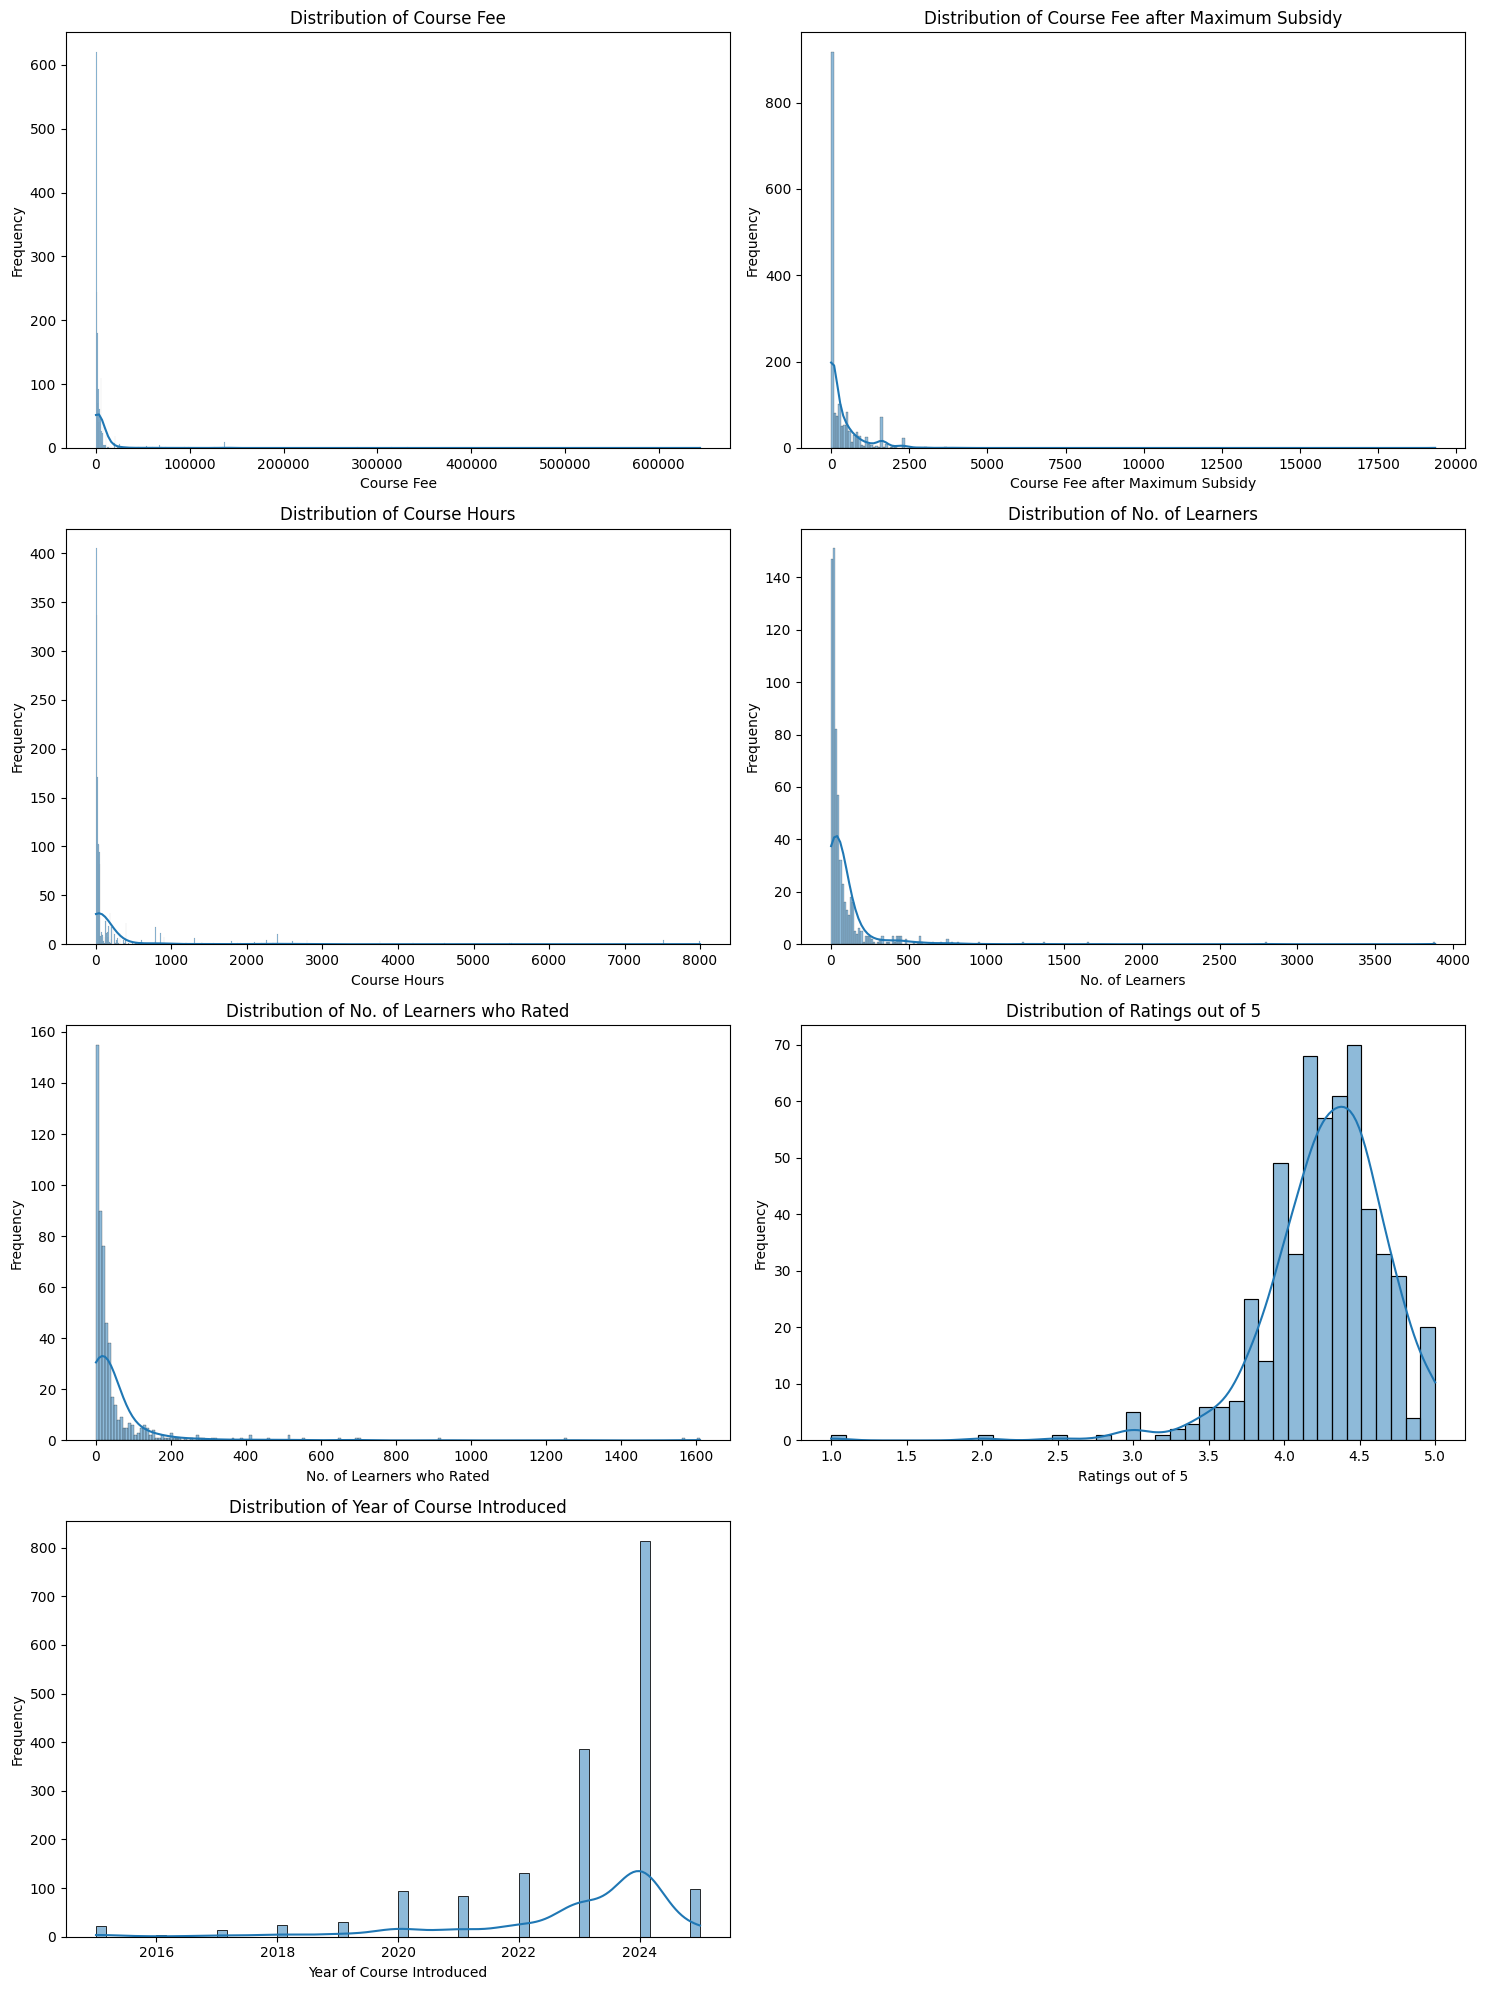

In [ ]:
# Histograms to check distributions
numerical_cols_dist = df_clean.select_dtypes(include=['float64', 'int64', 'int32']).columns

# Determine the number of rows needed for a 2-column layout
n_cols = 2
n_rows = (len(numerical_cols_dist) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array

for i, col in enumerate(numerical_cols_dist):
    sns.histplot(data=df_clean, x=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

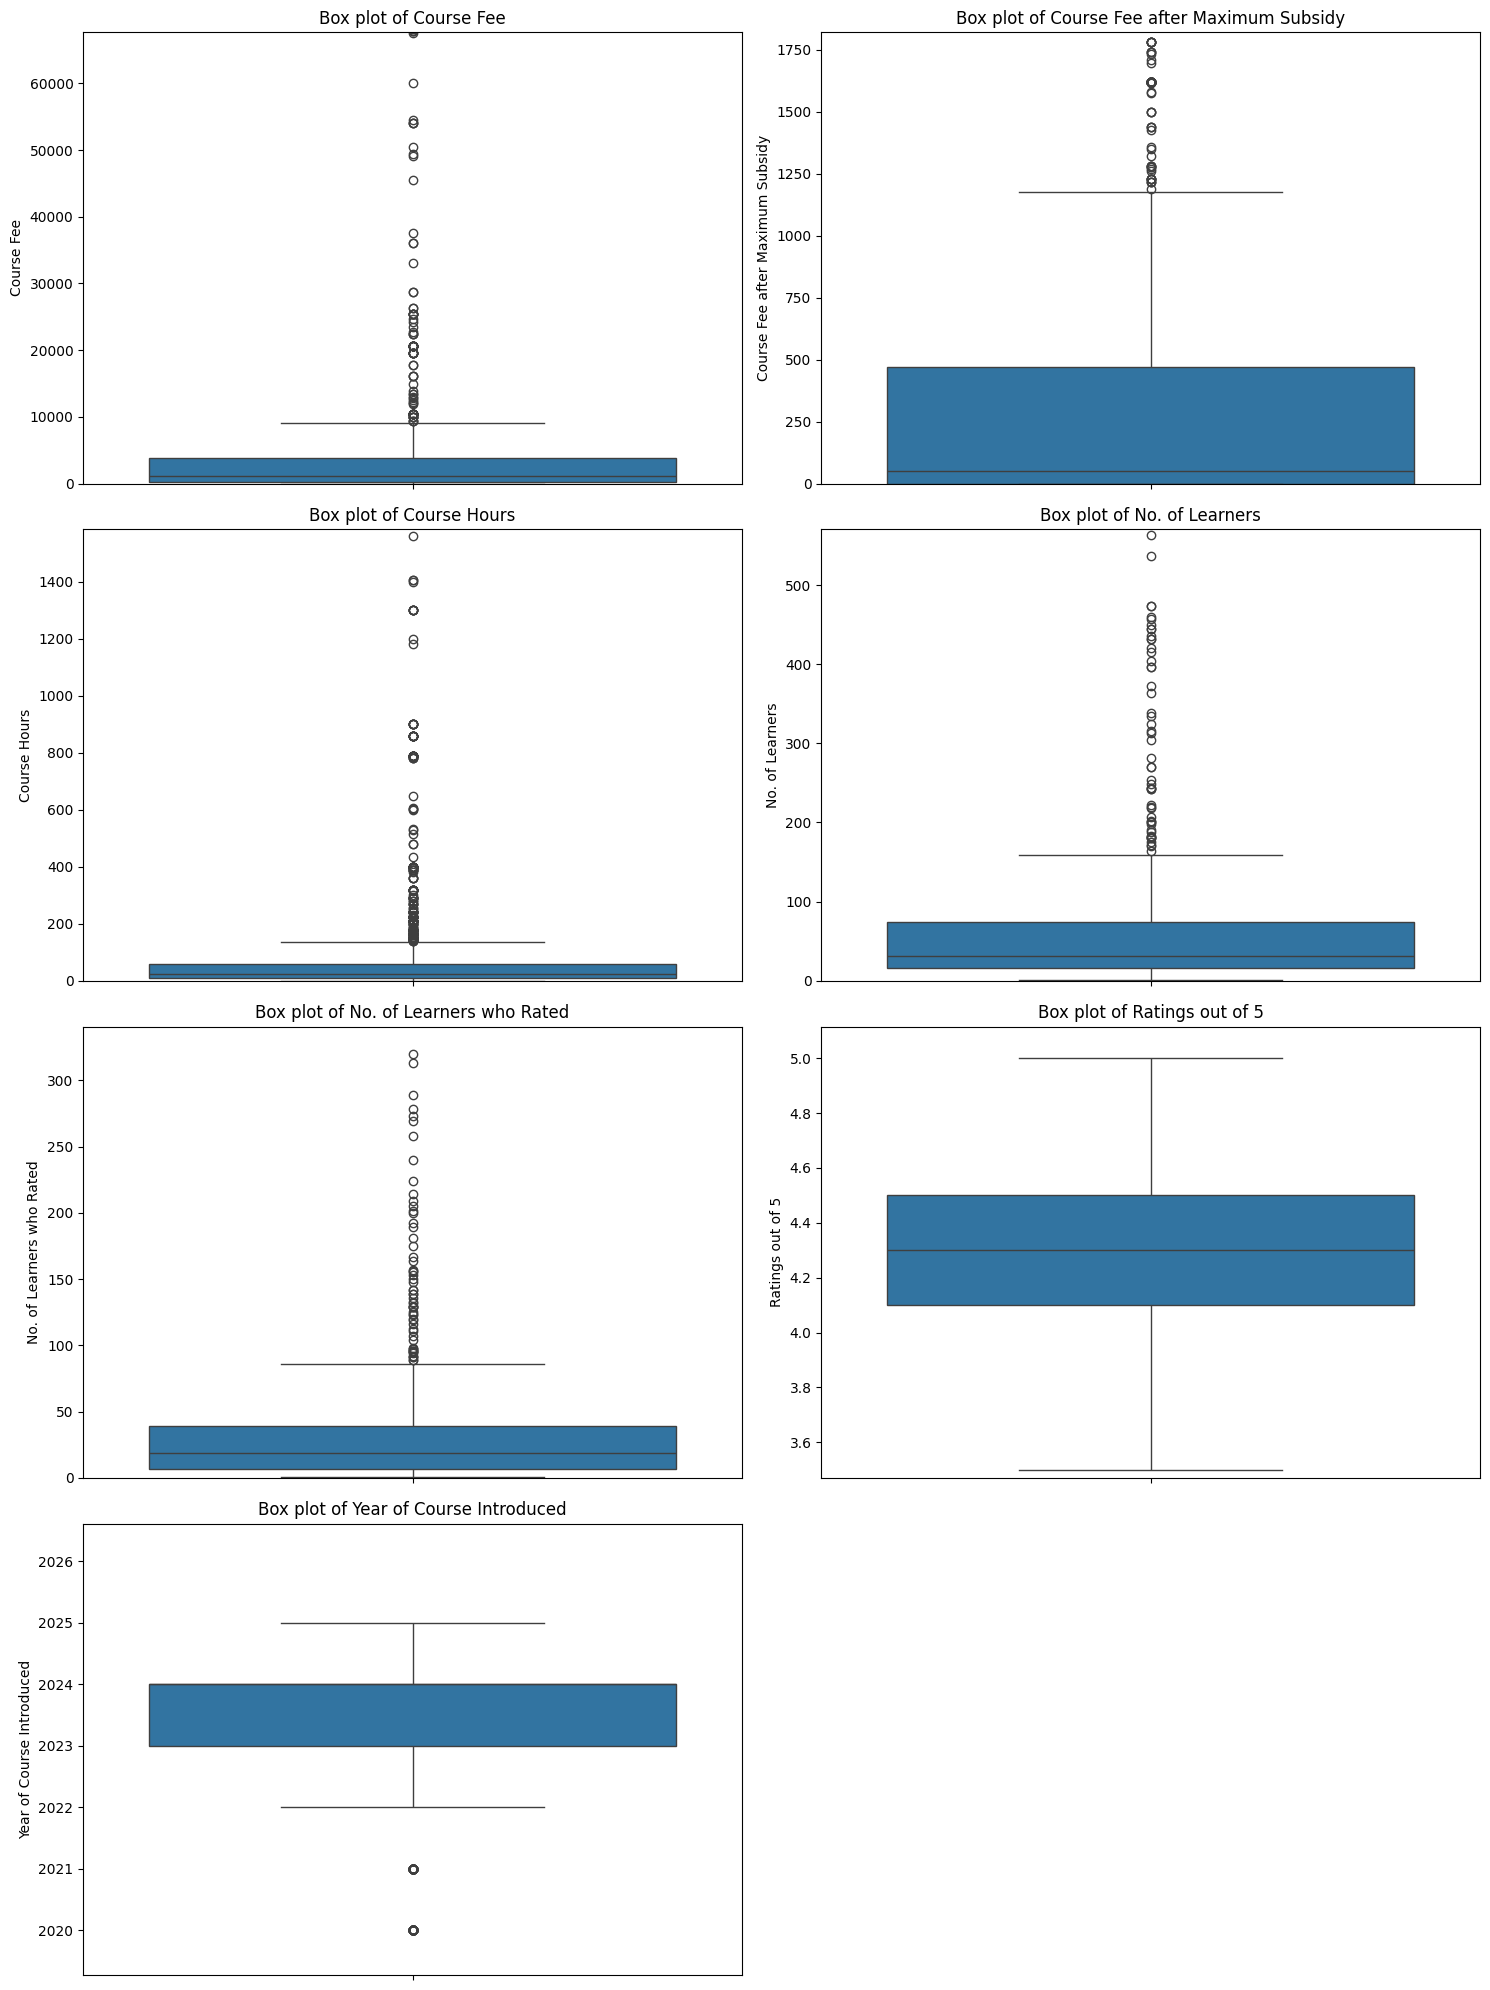

In [ ]:
# Boxplots to check all continous numerical columns for outliers
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64', 'int32']).columns

# Determine the number of rows needed for a 2-column layout
n_cols = 2
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() # Flatten the 2D array

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df_clean, y=col, ax=axes[i])
    axes[i].set_title(f'Box plot of {col}')
    axes[i].set_ylabel(col)

    # Calculate mean and standard deviation
    mean = df_clean[col].mean()
    std = df_clean[col].std()

    # Set y-axis limits to show up to two standard deviations, ensuring positive limits
    lower_limit = max(0, mean - 2 * std) # Ensure lower limit is not negative
    upper_limit = mean + 2 * std
    axes[i].set_ylim([lower_limit, upper_limit])


# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Function to find outliers
def find_outliers_iqr(df_out, column):
    Q1 = df_out[column].quantile(0.25)
    Q3 = df_out[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_out[(df_out[column] < lower_bound) | (df_out[column] > upper_bound)]
    return outliers

# Check course fees, course fees after subsidy, course hours for upper bound outliers
course_fee_outliers = find_outliers_iqr(df_clean, 'Course Fee')
subsidy_fee_outliers = find_outliers_iqr(df_clean, 'Course Fee after Maximum Subsidy')
course_hours_outliers = find_outliers_iqr(df_clean, 'Course Hours')

print("Outliers in 'Course Fee':")
display(course_fee_outliers[['Course Title', 'Training Company', 'Course Fee', 'Course Hours']].sort_values(by='Course Fee', ascending=False))

print("\nOutliers in 'Course Fee after Maximum Subsidy':")
display(subsidy_fee_outliers[['Course Title', 'Training Company', 'Course Fee', 'Course Fee after Maximum Subsidy', 'Course Hours']].sort_values(by='Course Fee after Maximum Subsidy', ascending=False))

print("\nOutliers in 'Course Hours':")
display(course_hours_outliers[['Course Title', 'Training Company', 'Course Fee', 'Course Hours']].sort_values(by='Course Hours', ascending=False))

Outliers in 'Course Fee':


,Course Title,Training Company,Course Fee,Course Hours
10,Bachelor of Dental Surgery,National University Of Singapore,644037.00,5200.0
11,Bachelor of Medicine and Bachelor of Surgery,National University Of Singapore,623364.00,5478.0
1184,Doctor of Philosophy,National University Of Singapore,332110.09,7520.0
1182,Doctor of Philosophy (CSI),National University Of Singapore,315422.00,7520.0
3,Doctor of Medicine (MD),National University Of Singapore,306075.00,6143.0
...,...,...,...,...
1204,Graduate Certificate of Psychotherapy,National University Of Singapore,10000.00,390.0
301,Specialist Diploma in Nursing (Gerontology),Nanyang Polytechnic,9918.00,380.0
46,Post Diploma Certificate in Advanced Clinical ...,Ngee Ann Polytechnic,9448.20,362.0
226,Post Diploma Certificate in Advanced Clinical ...,Ngee Ann Polytechnic,9396.00,360.0



Outliers in 'Course Fee after Maximum Subsidy':


,Course Title,Training Company,Course Fee,Course Fee after Maximum Subsidy,Course Hours
307,The Collaborative Practitioners Prescribing Pr...,National University Of Singapore,26325.0,19325.0,175.5
282,(SCTP) WSQ HIGHER CERTIFICATE IN HEALTHCARE (N...,Hmi Institute Of Health Sciences Pte. Ltd.,13828.0,4148.4,606.0
746,(SCTP) Advanced Certificate of Performance in ...,Singapore Polytechnic,12900.0,3870.0,360.0
283,(SCTP) WSQ HIGHER CERTIFICATE IN HEALTHCARE (N...,Hmi Institute Of Health Sciences Pte. Ltd.,12200.0,3660.0,532.0
403,(SCTP) WSQ HIGHER CERTIFICATE IN HEALTHCARE (T...,Hmi Institute Of Health Sciences Pte. Ltd.,12134.0,3640.2,529.0
...,...,...,...,...,...
1481,NUR6106 Specialty Organ Transplant Nursing I (...,Singapore Institute Of Technology,4100.0,1230.0,40.5
611,WSQ Higher Certificate in Healthcare (Operations),Ntuc Learninghub Pte. Ltd.,2433.0,1216.5,88.5
1139,Advanced Clinical Techniques For Retinal Disea...,National University Of Singapore,4050.0,1215.0,104.0
1159,Advanced Clinical Techniques For Anterior Eye ...,National University Of Singapore,4050.0,1215.0,104.0



Outliers in 'Course Hours':


,Course Title,Training Company,Course Fee,Course Hours
17,NUSMed Graduate Research Degree Programs,National University Of Singapore,69900.00,8000.0
1191,NUSMed Graduate Research Degree Programme - Do...,National University Of Singapore,68762.00,8000.0
1210,NUSMed Graduate Research Degree Programme - Ma...,National University Of Singapore,68762.00,8000.0
1184,Doctor of Philosophy,National University Of Singapore,332110.09,7520.0
1183,Doctor of Philosophy (PhD),National University Of Singapore,134954.00,7520.0
...,...,...,...,...
341,"DRG6103 Pelvic Sonography (Classroom, Synchron...",Singapore Institute Of Technology,3900.00,143.0
336,"DRG6107 Musculoskeletal Sonography (Classroom,...",Singapore Institute Of Technology,3900.00,143.0
615,WSQ Higher Certificate in Healthcare (Nursing),Ntuc Learninghub Pte. Ltd.,3850.00,140.0
299,Post-Diploma Certificate in Assessment of Lear...,Nanyang Polytechnic,3654.00,140.0


In [ ]:
# Check rows with 'No. of Learners' greater than or equal to 'No. of Learners who Rated'
inconsistent_learner_counts = df_clean[df_clean['No. of Learners'] < df_clean['No. of Learners who Rated']].copy()
inconsistent_learner_counts['Percentage Learners Rated'] = (inconsistent_learner_counts['No. of Learners who Rated'] / inconsistent_learner_counts['No. of Learners']) * 100

# Print the count of inconsistent rows
print(f"\nNumber of rows where 'No. of Learners' is less than 'No. of Learners who Rated': {len(inconsistent_learner_counts)}")

# Display the DataFrame
print("Rows where 'No. of Learners' is less than 'No. of Learners who Rated':")
display(inconsistent_learner_counts.sort_values(by='Percentage Learners Rated', ascending=False))


Number of rows where 'No. of Learners' is less than 'No. of Learners who Rated': 46
Rows where 'No. of Learners' is less than 'No. of Learners who Rated':


,ID,Course Title,Course Description,Training Company,Course Fee,Course Fee after Maximum Subsidy,Course Type,Course Duration,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced,Percentage Learners Rated
753,754,(SCTP) Certificate in Healthcare Administration,As Singapore edges towards our status as a sup...,Singapore University Of Social Sciences,6500.0,1950.00,Part Time,6 days - 1 month,80.0,43.0,205.0,4.3,2023,476.744186
423,424,Child First Aid,Course Objectives:\nTo provide participants wi...,Eversafe Academy Pte. Ltd.,200.0,100.00,Part Time,3-5 days,20.0,5.0,22.0,4.8,2023,440.000000
568,569,Beginning Artificial Intelligence Through Neur...,"Neuroscience helped inspire deep learning, whi...",National University Of Singapore,850.0,255.00,Part Time,1-2 days,7.5,1.0,4.0,2.8,2023,400.000000
377,378,(SCTP) Patient Service Associate (Full-Time) (...,Generation Singapores Patient Service Associa...,Temasek Polytechnic,10000.0,3000.00,Full Time,1-3 months,280.0,11.0,30.0,3.5,2022,272.727273
404,405,(SCTP) Certificate in Therapy Support (Healthc...,The WSQ Certificate in Therapy Support (Health...,Ntuc Learninghub Pte. Ltd.,7676.0,2302.80,Full Time,1-3 months,316.5,363.0,916.0,4.0,2022,252.341598
1557,1558,Industrial Attachment (ACBCCM),The industrial attachment will be for 10 days ...,Tsao Foundation,1400.0,420.00,Part Time,6 days - 1 month,70.0,19.0,31.0,4.3,2024,163.157895
1153,1154,Fundamentals of Simulation-Based Healthcare Ed...,This two-day workshop is designed to be intera...,National University Of Singapore,1700.0,510.00,Part Time,3-5 days,18.0,16.0,24.0,4.6,2024,150.000000
263,264,Ageing Process & Promotion of Physical Health,As per course description,Republic Polytechnic,1174.5,352.35,Full Time,6 days - 1 month,45.0,2.0,3.0,4.7,2021,150.000000
1585,1586,Customised Eldercare Training by Registered Nurse,Caregivers are able to care for the basic need...,Whiteangel Caregivers Consultancy (Private Lim...,210.0,0.00,Part Time,1-2 days,3.0,3.0,4.0,4.5,2024,133.333333
1559,1560,Care Coordination 101,Course Objective\nThe objective of this course...,Tsao Foundation,1180.0,354.00,Part Time,3-5 days,22.0,19.0,25.0,4.6,2024,131.578947


Min and Max Course Hours by Course Duration:


,min,max
Course Duration,,
1-2 days,0.33,14.0
3-5 days,14.50,35.0
6 days - 1 month,35.50,140.0
1-3 months,143.00,400.0
3-12 months,434.00,1560.0
More than 1 year,1800.00,8000.0


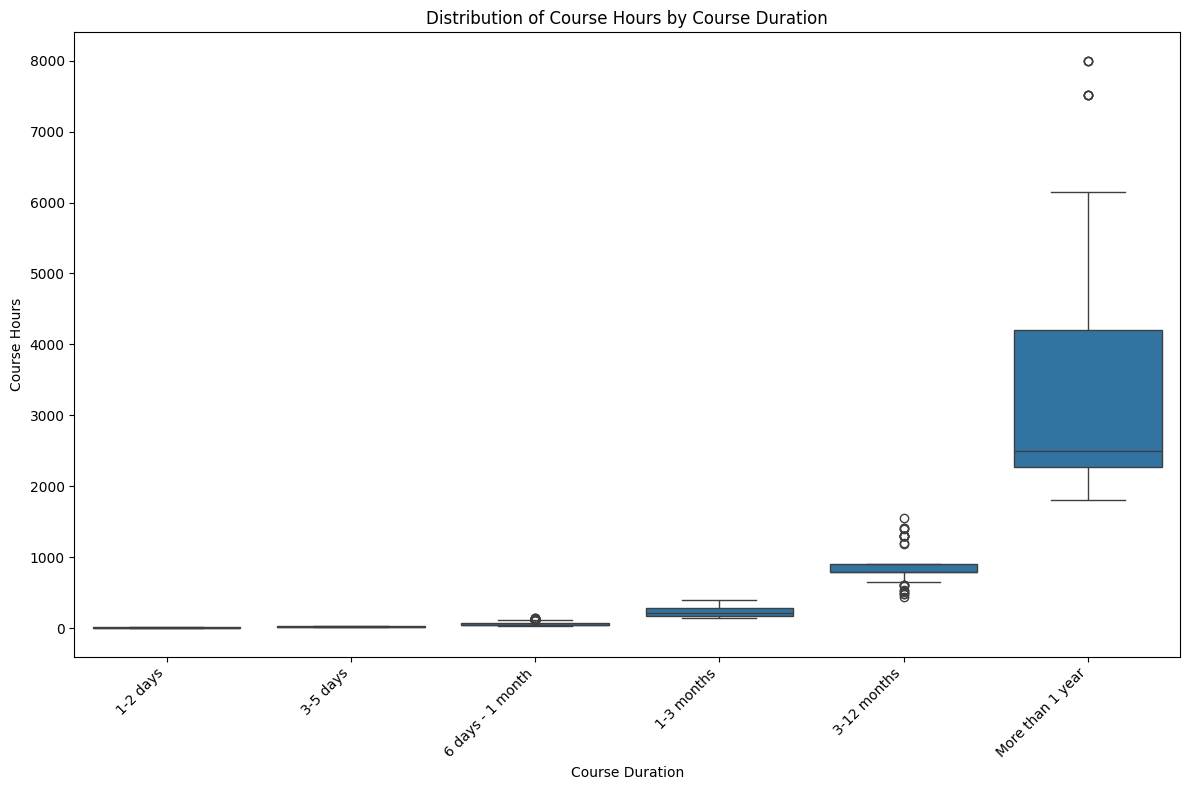

In [ ]:
# Check consistency of Course Duration by Course Hours
course_hours_by_duration = df_clean.groupby('Course Duration', observed=False)['Course Hours'].agg(['min', 'max'])

print("Min and Max Course Hours by Course Duration:")
display(course_hours_by_duration)

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_clean, x='Course Duration', y='Course Hours')
plt.title('Distribution of Course Hours by Course Duration')
plt.xlabel('Course Duration')
plt.ylabel('Course Hours')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

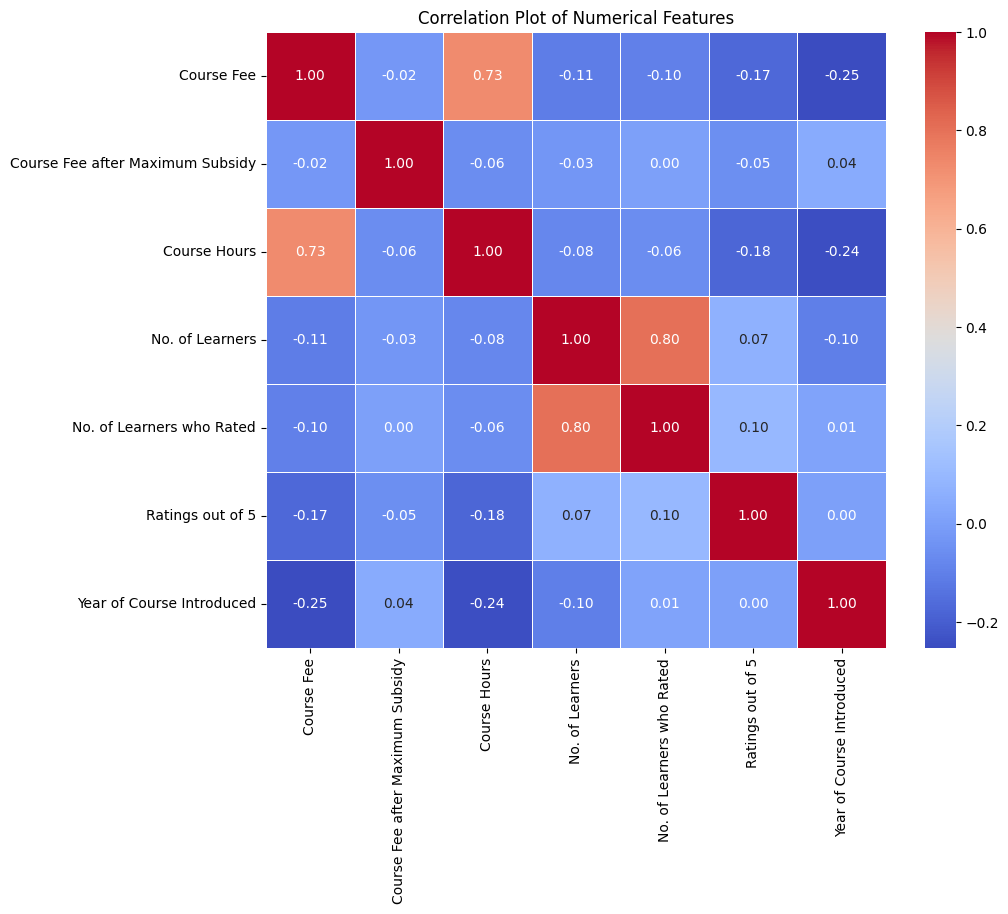

In [ ]:
# Select only numeric columns for correlation plot
numerical_cols = df_clean.select_dtypes(include=['float64', 'int64', 'int32']).columns
correlation_matrix = df_clean[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Plot of Numerical Features')
plt.show()

In [ ]:
# Analysis of records by training company
training_company_counts = df_clean['Training Company'].value_counts()
print("\nTraining Company Counts:")
display(training_company_counts.sort_values(ascending=False))


Training Company Counts:


,count
Training Company,
National University Of Singapore,318
Hmi Institute Of Health Sciences Pte. Ltd.,183
Nanyang Polytechnic,178
Republic Polytechnic,114
Ngee Ann Polytechnic,76
...,...
Social Service Institute (Ssi),1
Mind Transformations Pte Ltd,1
First Responders Limited Liability Partnership,1


,ID,Course Title,Course Description,Training Company,Course Fee,Course Fee after Maximum Subsidy,Course Type,Course Duration,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced
0,1,Nitec in Nursing,This course provides students with skills and ...,Institute Of Technical Education,860.0,0.0,Part Time,More than 1 year,2800.0,NaN,NaN,NaN,2015
1,2,Nitec in Opticianry,The Nitec in Opticianry course provides studen...,Institute Of Technical Education,860.0,0.0,Part Time,More than 1 year,2800.0,NaN,NaN,NaN,2015
2,3,Higher Nitec in Paramedic & Emergency Care,This course is to provide students with in-dep...,Institute Of Technical Education,885.0,0.0,Full Time and Part Time,More than 1 year,2100.0,NaN,NaN,NaN,2015
3,4,Doctor of Medicine (MD),The Duke-NUS Doctor of Medicine (MD) programme...,National University Of Singapore,306075.0,0.0,Part Time,More than 1 year,6143.0,NaN,NaN,NaN,2015
4,5,Doctor of Philosophy,The MSc and PhD programmes are research-intens...,National University Of Singapore,211000.0,0.0,Part Time,More than 1 year,7520.0,NaN,NaN,NaN,2015


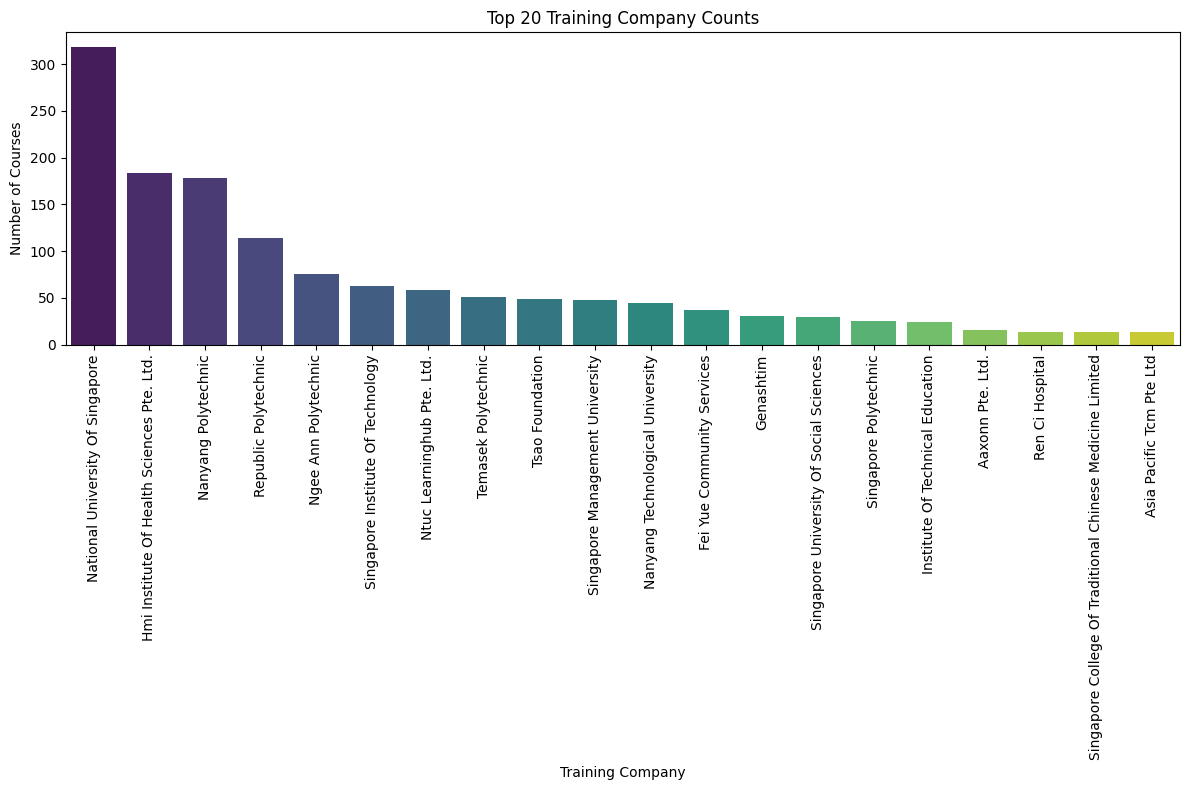

In [ ]:
# Define top 20 training companies by course count
top_20_companies = training_company_counts.head(20)
df_clean_top_20 = df_clean[df_clean['Training Company'].isin(top_20_companies.index.tolist())]
display(df_clean_top_20.head())

# Plot a bar chart for the top 20 training company counts
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_companies.index, y=top_20_companies.values, palette='viridis', hue=top_20_companies.index, legend=False)
plt.title('Top 20 Training Company Counts')
plt.xlabel('Training Company')
plt.ylabel('Number of Courses')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate course fee statistics for the top 20 training companies
course_fee_stats = df_clean_top_20.groupby('Training Company')['Course Fee'].agg(['min', 'mean', 'median', 'max', 'count'])

print("\nCourse Fee Statistics for Top 20 Training Companies:")
display(course_fee_stats.sort_values(by='count', ascending=False))


Course Fee Statistics for Top 20 Training Companies:


,min,mean,median,max,count
Training Company,,,,,
National University Of Singapore,850.00,18071.761572,4262.5,644037.00,318
Hmi Institute Of Health Sciences Pte. Ltd.,100.00,1080.281967,550.0,13828.00,183
Nanyang Polytechnic,90.00,6827.895562,4788.0,25470.00,178
Republic Polytechnic,55.00,2806.798246,1490.5,25470.00,114
Ngee Ann Polytechnic,260.00,6607.438158,2088.0,68100.00,76
Singapore Institute Of Technology,1200.00,28563.714286,3900.0,136920.00,63
Ntuc Learninghub Pte. Ltd.,100.00,1101.681034,440.0,7676.00,58
Temasek Polytechnic,29.99,6300.882157,1698.0,67800.00,51
Tsao Foundation,70.00,1116.938776,800.0,7620.00,49


In [ ]:
# Check % of missing learners by training company with count of courses
total_courses_by_company = df_clean['Training Company'].value_counts()

# Calculate the number of courses with missing learners by company
missing_learners_by_company = df_clean[df_clean['No. of Learners'].isna()].groupby('Training Company').size()

missing_learners_percentage = (missing_learners_by_company / total_courses_by_company)

missing_learners_summary = pd.DataFrame({
    'Total Courses': total_courses_by_company,
    'Courses with Missing Learners (NaN)': missing_learners_by_company,
    'Percentage Missing Learners': missing_learners_percentage
}).sort_values(by='Courses with Missing Learners (NaN)', ascending=False)

print("\nSummary of missing values in 'No. of Learners' by Training Company:")
display(missing_learners_summary.head(50).sort_values(by='Percentage Missing Learners', ascending=False).style.format({'Percentage Missing Learners': "{:.2%}"}))


Summary of missing values in 'No. of Learners' by Training Company:


,Total Courses,Courses with Missing Learners (NaN),Percentage Missing Learners
Training Company,,,
Aaxonn Pte. Ltd.,16,16.000000,100.00%
Genashtim,31,31.000000,100.00%
Silver Caregivers Co-Operative Limited,12,12.000000,100.00%
Asia Pacific Tcm Pte Ltd,13,13.000000,100.00%
Aria Training & Consultancy Pte. Ltd.,4,4.000000,100.00%
Anglo Nurses Pte. Ltd.,4,4.000000,100.00%
Island Maids (Group) Pte. Ltd.,3,3.000000,100.00%
St Luke'S Hospital,3,3.000000,100.00%
Home Nursing Foundation,5,5.000000,100.00%


In [ ]:
# Check occurence of missing learners by Course Type
missing_learners_by_type = df_clean[df_clean['No. of Learners'].isna()].groupby('Course Type').size().sort_values(ascending=False)

total_courses_by_type = df_clean['Course Type'].value_counts()

missing_learners_percentage = (missing_learners_by_type / total_courses_by_type)

missing_learners_type_summary = pd.DataFrame({
    'Total Courses': total_courses_by_type,
    'Course Type with Missing Learners (NaN)': missing_learners_by_type,
    'Percentage Missing Learners': missing_learners_percentage
}).sort_values(by='Course Type with Missing Learners (NaN)', ascending=False)

print("\nSummary of missing values in 'No. of Learners' by Course Type:")
display(missing_learners_type_summary.head(50).style.format({'Percentage Missing Learners': "{:.2%}"}))


Summary of missing values in 'No. of Learners' by Course Type:


,Total Courses,Course Type with Missing Learners (NaN),Percentage Missing Learners
Course Type,,,
Part Time,1321,790,59.80%
Full Time and Part Time,216,181,83.80%
Full Time,166,92,55.42%


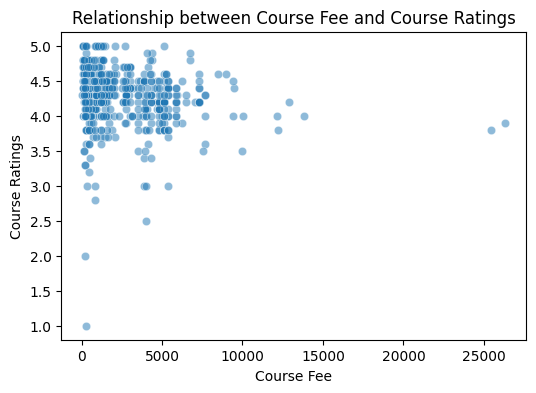

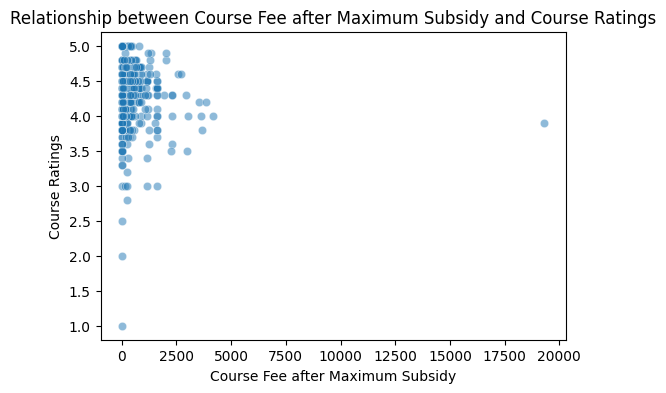

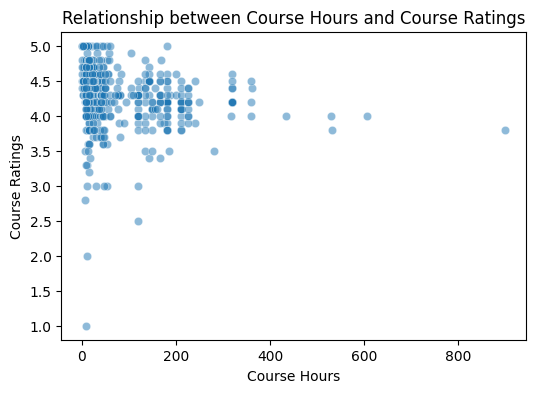

In [ ]:
# Scatter plots to visualize the relationship between numerical features and Ratings
numerical_cols_for_scatter = ['Course Fee', 'Course Fee after Maximum Subsidy', 'Course Hours']

for col in numerical_cols_for_scatter:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df_clean, x=col, y='Ratings out of 5', alpha=0.5)
    plt.title(f'Relationship between {col} and Course Ratings')
    plt.xlabel(col)
    plt.ylabel('Course Ratings')
    plt.show()

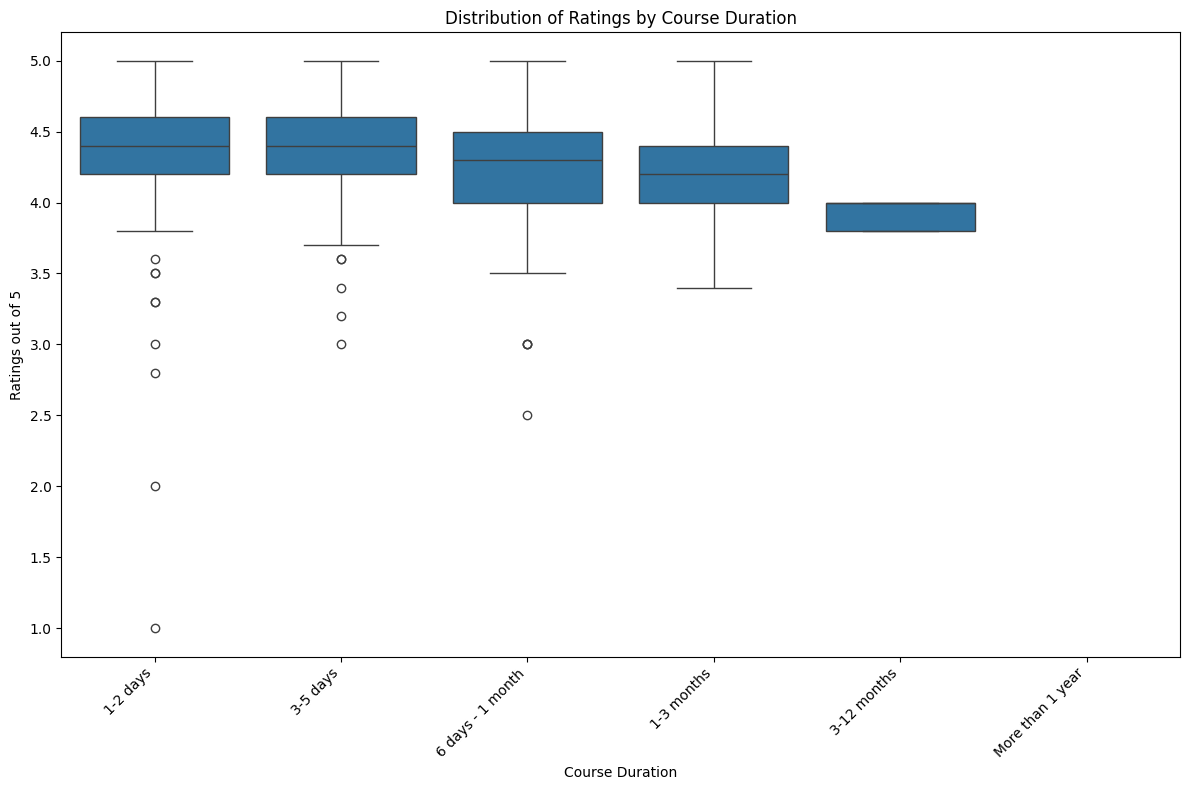

In [ ]:
# Box plot to visualise Distribution of Course Durations and Ratings
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_clean, x='Course Duration', y='Ratings out of 5')
plt.title('Distribution of Ratings by Course Duration')
plt.xlabel('Course Duration')
plt.ylabel('Ratings out of 5')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Feature Engineering

**Summary**

1. Created missing learners binary - revealed that shorter course hours/duration have less missing learners data.
2. Fee per hour column - To check if there are courses that are more expensive than others.
3. % of Subsidy column - Check if there are standard subsidy levels and which courses have more subsidy.

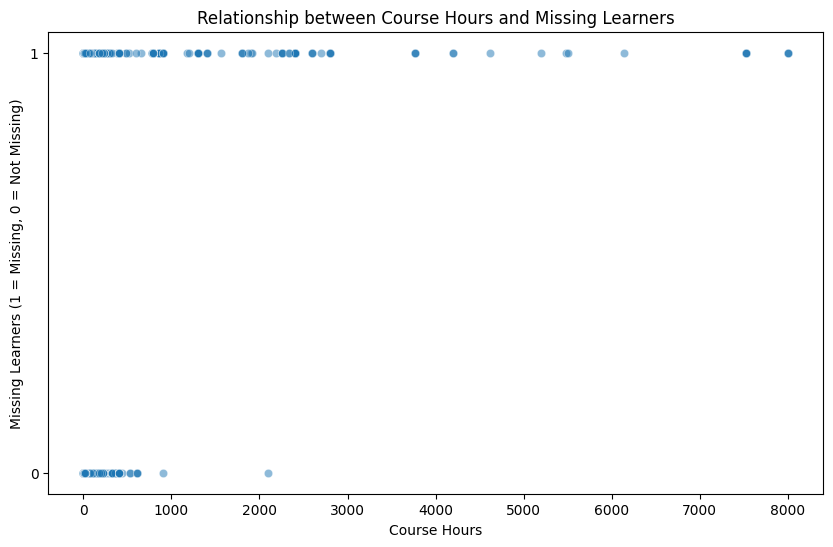

In [ ]:
# Create a binary column to indicate missing learners (1 if NaN, 0 otherwise)
df_clean['Missing Learners'] = df_clean['No. of Learners'].isna().astype(int)

# Scatter plot of Missing Learners vs Course Hours
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Course Hours', y='Missing Learners', alpha=0.5)
plt.title('Relationship between Course Hours and Missing Learners')
plt.xlabel('Course Hours')
plt.ylabel('Missing Learners (1 = Missing, 0 = Not Missing)')
plt.yticks([0, 1])
plt.show()


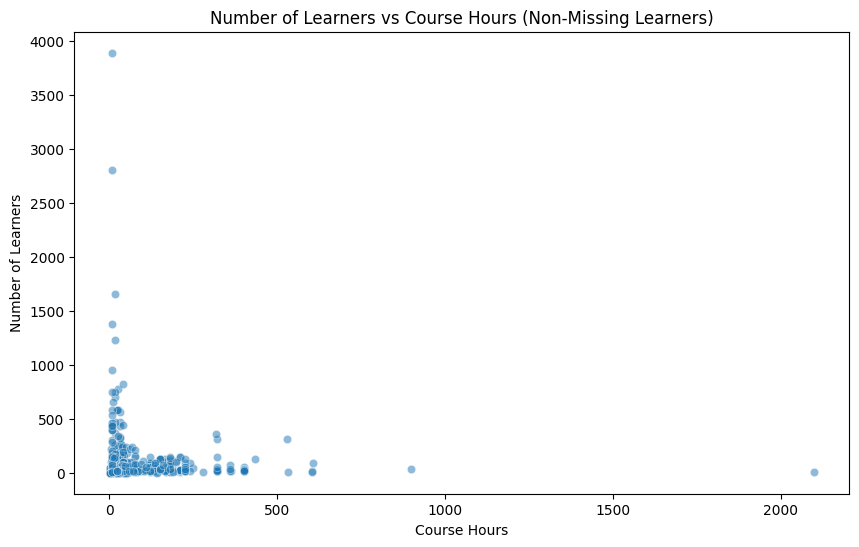

In [ ]:
# Create a scatter plot of 'No. of Learners' against 'Course Hours'
df_non_missing_learners = df_clean[df_clean['Missing Learners'] == 0].copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_non_missing_learners, x='Course Hours', y='No. of Learners', alpha=0.5)
plt.title('Number of Learners vs Course Hours (Non-Missing Learners)')
plt.xlabel('Course Hours')
plt.ylabel('Number of Learners')
plt.show()

,ID,Course Title,Course Description,Training Company,Course Fee,Course Fee after Maximum Subsidy,Course Type,Course Duration,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced,Missing Learners,Fee Per Hour
0,1,Nitec in Nursing,This course provides students with skills and ...,Institute Of Technical Education,860.00,0.0,Part Time,More than 1 year,2800.0,NaN,NaN,NaN,2015,1,0.307143
1,2,Nitec in Opticianry,The Nitec in Opticianry course provides studen...,Institute Of Technical Education,860.00,0.0,Part Time,More than 1 year,2800.0,NaN,NaN,NaN,2015,1,0.307143
2,3,Higher Nitec in Paramedic & Emergency Care,This course is to provide students with in-dep...,Institute Of Technical Education,885.00,0.0,Full Time and Part Time,More than 1 year,2100.0,NaN,NaN,NaN,2015,1,0.421429
17,18,NUSMed Graduate Research Degree Programs,Training of biomedical- and clinician-scienti...,National University Of Singapore,69900.00,0.0,Full Time and Part Time,More than 1 year,8000.0,NaN,NaN,NaN,2015,1,8.737500
15,16,Master of Nursing,To register with the Singapore Nursing Board t...,National University Of Singapore,36100.00,0.0,Full Time and Part Time,More than 1 year,2600.0,NaN,NaN,NaN,2015,1,13.884615
26,27,SkillsFuture@PA TCM Gua Sha (Stage 1),Learn the basics of TCM Gua Sha and massage/sc...,Changi Simei Community Club,140.00,0.0,Part Time,1-2 days,10.0,23.0,3.0,4.3,2017,0,14.000000
18,19,Graduate Diploma in Applied Epidemiology,The Graduate Diploma in Applied Epidemiology a...,National University Of Singapore,11916.00,0.0,Part Time,3-12 months,780.0,NaN,NaN,NaN,2015,1,15.276923
19,20,Graduate Diploma in Dental Implantology,This program was introduced to address the pro...,National University Of Singapore,22664.00,0.0,Part Time,3-12 months,1405.0,NaN,NaN,NaN,2015,1,16.130961
23,24,Medication for Common Ailments,This course aims to assist participants in the...,Nanyang Polytechnic,160.00,0.0,Part Time,1-2 days,8.0,NaN,NaN,NaN,2016,1,20.000000
25,26,NSA - Brain Gym for Mental Fitness,To learn a set of physical movements that woul...,Singapore Association For Continuing Education,140.00,0.0,Part Time,1-2 days,7.0,NaN,NaN,NaN,2016,1,20.000000


<Axes: >

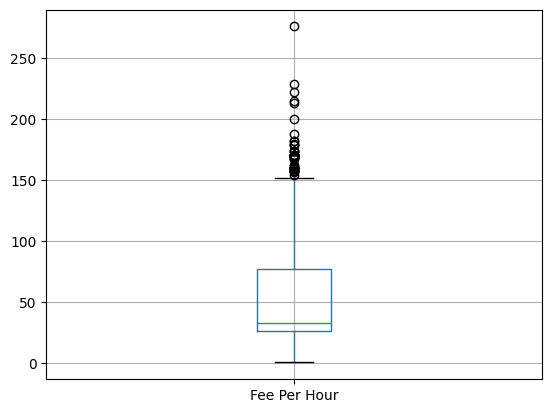

In [ ]:
# Create feature to calculate fee per hour
df_clean['Fee Per Hour'] = df_clean['Course Fee'] / df_clean['Course Hours']
df_clean['Fee Per Hour'] = df_clean['Fee Per Hour'].replace([float('inf'), float('-inf')], pd.NA)
display(df_clean.head(30).sort_values(by='Fee Per Hour', ascending=True))
display(df_clean.boxplot(column=['Fee Per Hour']))

In [ ]:
# Table of fee per hours stats sorted by highest average
fee_per_hour_stats = df_clean.groupby('Training Company')['Fee Per Hour'].agg(['min', 'mean', 'median', 'max', 'count'])
print("\nFee Per Hour Statistics by Training Companies:")
display(fee_per_hour_stats.head(50).sort_values(by='mean', ascending=False))


Fee Per Hour Statistics by Training Companies:


,min,mean,median,max,count
Training Company,,,,,
Aria Training & Consultancy Pte. Ltd.,100.000000,107.500000,100.000000,130.000000,4
Integrated Training Consultants Pte. Ltd.,73.333333,81.666667,81.666667,90.000000,2
Jaga-Me Pte. Ltd.,66.666667,75.833333,75.833333,85.000000,2
Island Maids (Group) Pte. Ltd.,21.428571,73.809524,100.000000,100.000000,3
Assure Safety Pte. Ltd.,22.500000,65.000000,66.875000,100.000000,6
Aaxonn Pte. Ltd.,27.500000,64.166667,55.000000,110.000000,16
Genashtim,58.333333,59.408602,58.333333,66.666667,31
Grace Management & Consultancy Services Pte. Ltd.,22.500000,59.062500,71.250000,71.250000,4
Mind Transformations Pte Ltd,55.000000,55.000000,55.000000,55.000000,1


In [ ]:
# Calculate the percentage difference between Course Fee and Course Fee after Maximum Subsidy
df_clean['Subsidy Percentage'] = ((df_clean['Course Fee'] - df_clean['Course Fee after Maximum Subsidy']) / df_clean['Course Fee']) * 100

# Check column
display(df_clean.head(50))

# Display the count of unique values in 'Subsidy Percentage'
print("\nUnique values and their counts in 'Subsidy Percentage':")
display(df_clean['Subsidy Percentage'].value_counts())

,ID,Course Title,Course Description,Training Company,Course Fee,Course Fee after Maximum Subsidy,Course Type,Course Duration,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced,Missing Learners,Fee Per Hour,Subsidy Percentage
0,1,Nitec in Nursing,This course provides students with skills and ...,Institute Of Technical Education,860.00,0.0,Part Time,More than 1 year,2800.0,NaN,NaN,NaN,2015,1,0.307143,100.0
1,2,Nitec in Opticianry,The Nitec in Opticianry course provides studen...,Institute Of Technical Education,860.00,0.0,Part Time,More than 1 year,2800.0,NaN,NaN,NaN,2015,1,0.307143,100.0
2,3,Higher Nitec in Paramedic & Emergency Care,This course is to provide students with in-dep...,Institute Of Technical Education,885.00,0.0,Full Time and Part Time,More than 1 year,2100.0,NaN,NaN,NaN,2015,1,0.421429,100.0
3,4,Doctor of Medicine (MD),The Duke-NUS Doctor of Medicine (MD) programme...,National University Of Singapore,306075.00,0.0,Part Time,More than 1 year,6143.0,NaN,NaN,NaN,2015,1,49.825004,100.0
4,5,Doctor of Philosophy,The MSc and PhD programmes are research-intens...,National University Of Singapore,211000.00,0.0,Part Time,More than 1 year,7520.0,NaN,NaN,NaN,2015,1,28.058511,100.0
5,6,Master of Clinical Investigation,The primary aim of this programme is to grow t...,National University Of Singapore,49346.00,0.0,Full Time,3-12 months,480.0,NaN,NaN,NaN,2015,1,102.804167,100.0
6,7,Master of Dental Surgery,To provide residency training programmes leadi...,National University Of Singapore,98650.00,0.0,Full Time,3-12 months,1182.0,NaN,NaN,NaN,2015,1,83.460237,100.0
7,8,Master of Public Health,The Master of Public Health (MPH) is a profess...,National University Of Singapore,94050.00,0.0,Full Time,3-12 months,1560.0,NaN,NaN,NaN,2015,1,60.288462,100.0
8,9,Master of Science (Speech and Language Pathology),The M.Sc. (SLP) programme is an entry-level tr...,National University Of Singapore,84700.00,0.0,Full Time,More than 1 year,2700.0,NaN,NaN,NaN,2015,1,31.370370,100.0
9,10,Bachelor of Science (Nursing),To register with the Singapore Nursing Board t...,National University Of Singapore,104439.00,0.0,Full Time,More than 1 year,4613.0,NaN,NaN,NaN,2015,1,22.640147,100.0



Unique values and their counts in 'Subsidy Percentage':


,count
Subsidy Percentage,
100.000000,835
70.000000,684
50.000000,179
71.666667,3
26.590693,1
82.985075,1


Top 20 Training Companies with the Most Fully Subsidized Courses:


,count
Training Company,
Nanyang Polytechnic,169
Ngee Ann Polytechnic,51
National University Of Singapore,46
Hmi Institute Of Health Sciences Pte. Ltd.,43
Republic Polytechnic,40
Fei Yue Community Services,37
Genashtim,31
Singapore University Of Social Sciences,23
Temasek Polytechnic,20


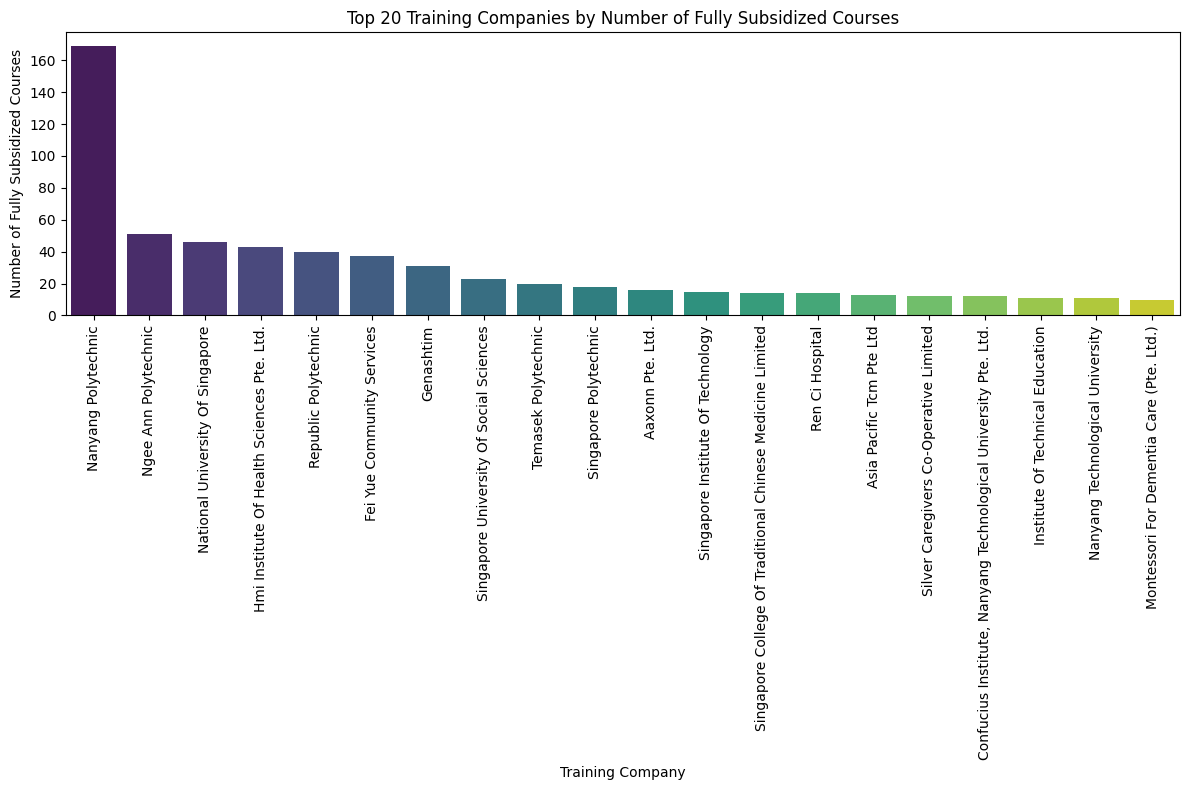

In [ ]:
# Filter the DataFrame for courses with 100% subsidy
fully_subsidized_courses = df_clean[df_clean['Subsidy Percentage'] == 100]

# Group by training company and count the number of fully subsidized courses
fully_subsidized_counts = fully_subsidized_courses['Training Company'].value_counts()

# Select the top 20 training companies with the most fully subsidized courses
top_20_fully_subsidized_companies = fully_subsidized_counts.head(20)

print("Top 20 Training Companies with the Most Fully Subsidized Courses:")
display(top_20_fully_subsidized_companies)

# Create a bar chart of the top 20 training companies with the most fully subsidized courses
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_fully_subsidized_companies.index, y=top_20_fully_subsidized_companies.values, palette='viridis', hue=top_20_fully_subsidized_companies.index, legend=False)
plt.title('Top 20 Training Companies by Number of Fully Subsidized Courses')
plt.xlabel('Training Company')
plt.ylabel('Number of Fully Subsidized Courses')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

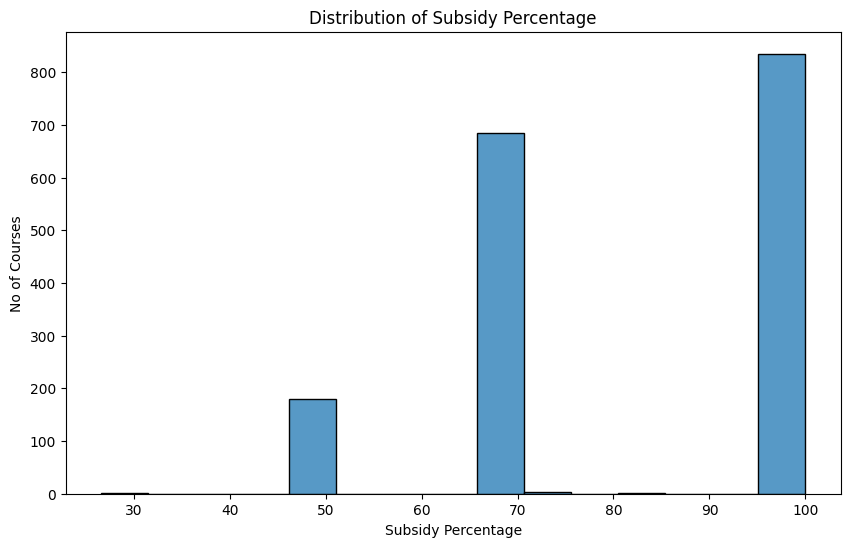

In [ ]:
# Visualize the distribution of 'Percentage Fee Reduction'
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='Subsidy Percentage', bins='auto')
plt.title('Distribution of Subsidy Percentage')
plt.xlabel('Subsidy Percentage')
plt.ylabel('No of Courses')
plt.show()

In [ ]:
# Check final cleaned dataframe
display(df_clean.head(50))

,ID,Course Title,Course Description,Training Company,Course Fee,Course Fee after Maximum Subsidy,Course Type,Course Duration,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced,Missing Learners,Fee Per Hour,Subsidy Percentage
0,1,Nitec in Nursing,This course provides students with skills and ...,Institute Of Technical Education,860.00,0.0,Part Time,More than 1 year,2800.0,NaN,NaN,NaN,2015,1,0.307143,100.0
1,2,Nitec in Opticianry,The Nitec in Opticianry course provides studen...,Institute Of Technical Education,860.00,0.0,Part Time,More than 1 year,2800.0,NaN,NaN,NaN,2015,1,0.307143,100.0
2,3,Higher Nitec in Paramedic & Emergency Care,This course is to provide students with in-dep...,Institute Of Technical Education,885.00,0.0,Full Time and Part Time,More than 1 year,2100.0,NaN,NaN,NaN,2015,1,0.421429,100.0
3,4,Doctor of Medicine (MD),The Duke-NUS Doctor of Medicine (MD) programme...,National University Of Singapore,306075.00,0.0,Part Time,More than 1 year,6143.0,NaN,NaN,NaN,2015,1,49.825004,100.0
4,5,Doctor of Philosophy,The MSc and PhD programmes are research-intens...,National University Of Singapore,211000.00,0.0,Part Time,More than 1 year,7520.0,NaN,NaN,NaN,2015,1,28.058511,100.0
5,6,Master of Clinical Investigation,The primary aim of this programme is to grow t...,National University Of Singapore,49346.00,0.0,Full Time,3-12 months,480.0,NaN,NaN,NaN,2015,1,102.804167,100.0
6,7,Master of Dental Surgery,To provide residency training programmes leadi...,National University Of Singapore,98650.00,0.0,Full Time,3-12 months,1182.0,NaN,NaN,NaN,2015,1,83.460237,100.0
7,8,Master of Public Health,The Master of Public Health (MPH) is a profess...,National University Of Singapore,94050.00,0.0,Full Time,3-12 months,1560.0,NaN,NaN,NaN,2015,1,60.288462,100.0
8,9,Master of Science (Speech and Language Pathology),The M.Sc. (SLP) programme is an entry-level tr...,National University Of Singapore,84700.00,0.0,Full Time,More than 1 year,2700.0,NaN,NaN,NaN,2015,1,31.370370,100.0
9,10,Bachelor of Science (Nursing),To register with the Singapore Nursing Board t...,National University Of Singapore,104439.00,0.0,Full Time,More than 1 year,4613.0,NaN,NaN,NaN,2015,1,22.640147,100.0


# Prepared Modelling Dataset for Problem Statement

1. Removed rows where there are NaN values in learners, learners who rated, and ratings
2. Export to CSV for Part C

In [ ]:
# Create a new DataFrame without missing rows
df_prepared = df_clean.dropna().copy()

# Check shape of the new DataFrame vs old
print("\nShape of the original DataFrame:", df_clean.shape)
print("Shape of the new DataFrame after dropping missing values:", df_prepared.shape)
display(df_prepared.sort_values(by='No. of Learners who Rated', ascending=False))


Shape of the original DataFrame: (1703, 16)
Shape of the new DataFrame after dropping missing values: (532, 16)


,ID,Course Title,Course Description,Training Company,Course Fee,Course Fee after Maximum Subsidy,Course Type,Course Duration,Course Hours,No. of Learners,No. of Learners who Rated,Ratings out of 5,Year of Course Introduced,Missing Learners,Fee Per Hour,Subsidy Percentage
811,812,STANDARD FIRST AID PROVIDER CERTIFICATION (BLE...,"Upon completing this course, learners will hav...",Aetos Training Academy Pte. Ltd.,320.0,160.0,Part Time,3-5 days,16.0,1655.0,1610.0,4.8,2024,0,20.000000,50.0
272,273,CERT FIRST AID COURSE,To train CERT First Aiders to be able to rende...,Cosem Safety & Security Services Pte. Ltd.,130.0,65.0,Part Time,1-2 days,7.5,2798.0,1568.0,4.6,2021,0,17.333333,50.0
812,813,BCLS+AED PROVIDER CERTIFICATION (Asynchronous ...,"Upon completing this course, learners will hav...",Aetos Training Academy Pte. Ltd.,238.0,119.0,Full Time and Part Time,1-2 days,8.0,1377.0,1256.0,4.8,2024,0,29.750000,50.0
404,405,(SCTP) Certificate in Therapy Support (Healthc...,The WSQ Certificate in Therapy Support (Health...,Ntuc Learninghub Pte. Ltd.,7676.0,2302.8,Full Time,1-3 months,316.5,363.0,916.0,4.0,2022,0,24.252765,70.0
188,189,Basic Cardiac Life Support with AED (Asynchron...,- Identify the signs and symptoms of cardiac a...,Singapore Emergency Responder Academy,150.0,75.0,Part Time,1-2 days,8.0,3887.0,703.0,4.5,2020,0,18.750000,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,205,Modular Certificate in Prehospital Management ...,The course aims to deepen students knowledge ...,Nanyang Polytechnic,5094.0,0.0,Full Time,1-3 months,180.0,20.0,1.0,5.0,2021,0,28.300000,100.0
169,170,Frontline Services Management,Equips learner with the knowledge and skills t...,Hmi Institute Of Health Sciences Pte. Ltd.,902.0,451.0,Part Time,6 days - 1 month,41.0,47.0,1.0,5.0,2020,0,22.000000,50.0
167,168,NSA - Chronic Diseases of TCM Management Modul...,Understand the principle of health and immunit...,Fei Yue Community Services,260.0,0.0,Part Time,1-2 days,12.0,16.0,1.0,5.0,2020,0,21.666667,100.0
168,169,Practice Infection Prevention and Control in H...,This module designed to equip learner with kno...,Hmi Institute Of Health Sciences Pte. Ltd.,902.0,451.0,Full Time,6 days - 1 month,41.0,47.0,1.0,4.0,2020,0,22.000000,50.0


In [ ]:
# Export the cleaned DataFrame to a CSV file for PartC
df_prepared.to_csv('SSG_Healthcare_Courses_Cleaned.csv', index=False)